In [55]:
# import kagglehub

# # Download latest version of Dataset
# path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

# print("", path)

In [56]:
# Import pandas and read dataset
import pandas as pd

songs_file = "spotify_songs.csv"

df = pd.read_csv(songs_file,parse_dates=True,index_col=0)

C:\Users\natha\AppData\Local\Temp\ipykernel_33984\2063993067.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(songs_file,parse_dates=True,index_col=0)


In [57]:
df.head(3)

,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_id,,,,,,,,,,,,,,,,,,,,,
6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


In [58]:
# Choosing desired features
features = ["track_popularity", "danceability", "energy", "mode", "key", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

In [59]:
df_binned = df[features].copy()

In [60]:
# Here, df_binned is just a copy of df
df_binned.head(3)

,track_popularity,danceability,energy,mode,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_id,,,,,,,,,,,,,
6f807x0ima9a1j3VPbc7VN,66,0.748,0.916,1,6,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
0r7CVbZTWZgbTCYdfa2P31,67,0.726,0.815,1,11,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
1z1Hg7Vb0AhHDiEmnDE79l,70,0.675,0.931,0,1,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


In [61]:
# Categorize each column into 3 different bins (High,Medium,Low)
def bin_feature(series):
    return pd.cut(series, 
                  bins=3, 
                  labels=[f'Low', 
                          f'Medium', 
                          f'High']
                          )

In [62]:
# Add binned columns to df_binned
for feature in features:
    df_binned[f'{feature}_binned'] = bin_feature(df[feature])

In [63]:
# Here, df_binned has both original and binned columns
df_binned.head(3)

,track_popularity,danceability,energy,mode,key,loudness,speechiness,acousticness,instrumentalness,liveness,...,mode_binned,key_binned,loudness_binned,speechiness_binned,acousticness_binned,instrumentalness_binned,liveness_binned,valence_binned,tempo_binned,duration_ms_binned
track_id,,,,,,,,,,,,,,,,,,,,,
6f807x0ima9a1j3VPbc7VN,66,0.748,0.916,1,6,-2.634,0.0583,0.1020,0.000000,0.0653,...,High,Medium,High,Low,Low,Low,Low,Medium,Medium,Medium
0r7CVbZTWZgbTCYdfa2P31,67,0.726,0.815,1,11,-4.969,0.0373,0.0724,0.004210,0.3570,...,High,High,High,Low,Low,Low,Medium,High,Medium,Low
1z1Hg7Vb0AhHDiEmnDE79l,70,0.675,0.931,0,1,-3.432,0.0742,0.0794,0.000023,0.1100,...,Low,Low,High,Low,Low,Low,Low,Medium,Medium,Medium


In [64]:
# Add the names of the binned columns to a list 
binned_columns = [col for col in df_binned.columns if '_binned' in col]


In [65]:
binned_columns

['track_popularity_binned',
 'danceability_binned',
 'energy_binned',
 'mode_binned',
 'key_binned',
 'loudness_binned',
 'speechiness_binned',
 'acousticness_binned',
 'instrumentalness_binned',
 'liveness_binned',
 'valence_binned',
 'tempo_binned',
 'duration_ms_binned']

In [66]:
# df_transactions is now a DataFrame with only the binned columns
df_transactions = df_binned[binned_columns]

In [67]:
df_transactions.head(3)

,track_popularity_binned,danceability_binned,energy_binned,mode_binned,key_binned,loudness_binned,speechiness_binned,acousticness_binned,instrumentalness_binned,liveness_binned,valence_binned,tempo_binned,duration_ms_binned
track_id,,,,,,,,,,,,,
6f807x0ima9a1j3VPbc7VN,Medium,High,High,High,Medium,High,Low,Low,Low,Low,Medium,Medium,Medium
0r7CVbZTWZgbTCYdfa2P31,High,High,High,High,High,High,Low,Low,Low,Medium,High,Medium,Low
1z1Hg7Vb0AhHDiEmnDE79l,High,High,High,Low,Low,High,Low,Low,Low,Low,Medium,Medium,Medium


In [68]:
df_transactions.iloc[0]

track_popularity_binned    Medium
danceability_binned          High
energy_binned                High
mode_binned                  High
key_binned                 Medium
loudness_binned              High
speechiness_binned            Low
acousticness_binned           Low
instrumentalness_binned       Low
liveness_binned               Low
valence_binned             Medium
tempo_binned               Medium
duration_ms_binned         Medium
Name: 6f807x0ima9a1j3VPbc7VN, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [69]:
# In order to use apriori, values must be turned to 0/1 or True/False.
# SO, we will turn our DataFrame into a list of Lists (of Strings) and 
# transform our data into form (col_name=row_val[High/Medium/Low]).

# Using axis=1 and lambda function to go over one row (song) at a time 
# take the data from df_transactions and turn each row into a list (one transaction). 
# Add all lists to the transactions list

transactions = df_transactions.astype(str).apply(
    lambda row: [f'{col}={row[col]}' for col in binned_columns],
    axis=1
).tolist()

In [70]:
# transactions is now the data from df_transactions in List format
transactions[0]

['track_popularity_binned=Medium',
 'danceability_binned=High',
 'energy_binned=High',
 'mode_binned=High',
 'key_binned=Medium',
 'loudness_binned=High',
 'speechiness_binned=Low',
 'acousticness_binned=Low',
 'instrumentalness_binned=Low',
 'liveness_binned=Low',
 'valence_binned=Medium',
 'tempo_binned=Medium',
 'duration_ms_binned=Medium']

In [71]:

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)


In [72]:
# te_array is transactions as a matrix of True/False values 
te_array

array([[False,  True, False, ..., False, False,  True],
       [False,  True, False, ...,  True, False, False],
       [False,  True, False, ..., False, False,  True],
       ...,
       [False,  True, False, ..., False, False,  True],
       [False,  True, False, ..., False,  True, False],
       [False,  True, False, ..., False,  True, False]], shape=(32833, 38))

In [73]:
# Apriori won't work directly on lists, so we move our data back 
# into a DataFrame
df_encoded = pd.DataFrame(te_array,columns=te.columns_)

In [75]:
# We are back to a DataFrame, this time with Trues and Falses
df_encoded.head(3)

,acousticness_binned=High,acousticness_binned=Low,acousticness_binned=Medium,danceability_binned=High,danceability_binned=Low,danceability_binned=Medium,duration_ms_binned=High,duration_ms_binned=Low,duration_ms_binned=Medium,energy_binned=High,...,speechiness_binned=Medium,tempo_binned=High,tempo_binned=Low,tempo_binned=Medium,track_popularity_binned=High,track_popularity_binned=Low,track_popularity_binned=Medium,valence_binned=High,valence_binned=Low,valence_binned=Medium
0,False,True,False,True,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,True
1,False,True,False,True,False,False,False,True,False,True,...,False,False,False,True,True,False,False,True,False,False
2,False,True,False,True,False,False,False,False,True,True,...,False,False,False,True,True,False,False,False,False,True


In [ ]:
from mlxtend.frequent_patterns import apriori

# Run apriori on our Data
frequent_itemsets = apriori(
    df_encoded,
    min_support = 0.05,
    use_colnames=True,
    max_len=3
)

In [ ]:
frequent_itemsets.head(3)

,support,itemsets
0,0.054701,frozenset({acousticness_binned=High})
1,0.807267,frozenset({acousticness_binned=Low})
2,0.138032,frozenset({acousticness_binned=Medium})


In [76]:
frequent_itemsets.sort_values('support', ascending=False).head(3)

,support,itemsets
16,0.981908,frozenset({loudness_binned=High})
19,0.933147,frozenset({speechiness_binned=Low})
260,0.916121,"frozenset({speechiness_binned=Low, loudness_bi..."


In [77]:
frequent_itemsets.head(3)

,support,itemsets
0,0.054701,frozenset({acousticness_binned=High})
1,0.807267,frozenset({acousticness_binned=Low})
2,0.138032,frozenset({acousticness_binned=Medium})


In [ ]:
frequent_itemsets['itemsets'].apply(len).value_counts()

itemsets
3    1381
2     281
1      29
Name: count, dtype: int64

In [ ]:
# Extract rules 

# Key Metrics :
# support -> how common the rule is (eg. "7% of all songs have all items in the rule (antecedents + consequents).")
# confidence -> how reliable the rule is (eg. "Among songs that satisfy the antecedent, 65% also satisfy the consequent.")
# lift -> (eg. "The consequent is 42% more likely when the antecedent occurs than in the dataset overall.")
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)


In [ ]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({acousticness_binned=High}),frozenset({speechiness_binned=Low}),0.054701,0.933147,0.051442,0.940423,1.007798,1.0,0.000398,1.122139,0.008185,0.054936,0.108845,0.497775
1,frozenset({acousticness_binned=Low}),frozenset({danceability_binned=High}),0.807267,0.541742,0.441416,0.546802,1.009342,1.0,0.004086,1.011167,0.048023,0.486359,0.011044,0.680806
2,frozenset({danceability_binned=High}),frozenset({acousticness_binned=Low}),0.541742,0.807267,0.441416,0.814809,1.009342,1.0,0.004086,1.040723,0.020197,0.486359,0.039129,0.680806
3,frozenset({danceability_binned=Medium}),frozenset({acousticness_binned=Low}),0.434685,0.807267,0.348034,0.800659,0.991814,1.0,-0.002873,0.966849,-0.014390,0.389336,-0.034288,0.615892
4,frozenset({duration_ms_binned=Low}),frozenset({acousticness_binned=Low}),0.162824,0.807267,0.123443,0.758137,0.939140,1.0,-0.008000,0.796868,-0.071846,0.145802,-0.254913,0.455526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3237,"frozenset({valence_binned=Low, track_popularit...",frozenset({tempo_binned=Medium}),0.091615,0.860689,0.081838,0.893285,1.037872,1.0,0.002986,1.305444,0.040170,0.094017,0.233977,0.494185
3238,"frozenset({valence_binned=Medium, track_popula...",frozenset({tempo_binned=Medium}),0.146529,0.860689,0.126275,0.861775,1.001262,1.0,0.000159,1.007858,0.001477,0.143341,0.007797,0.504245
3239,"frozenset({valence_binned=High, track_populari...",frozenset({tempo_binned=Medium}),0.136144,0.860689,0.115981,0.851902,0.989790,1.0,-0.001196,0.940665,-0.011800,0.131669,-0.063077,0.493328
3240,"frozenset({valence_binned=Low, track_popularit...",frozenset({tempo_binned=Medium}),0.119818,0.860689,0.104072,0.868582,1.009170,1.0,0.000946,1.060057,0.010324,0.118745,0.056655,0.494749


In [79]:
rules.sort_values('lift',ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
913,"frozenset({liveness_binned=Low, acousticness_b...",frozenset({energy_binned=Medium}),0.123352,0.351445,0.074072,0.600494,1.708641,1.0,0.030721,1.623391,0.473097,0.184845,0.384006,0.405629
915,frozenset({acousticness_binned=Medium}),"frozenset({liveness_binned=Low, energy_binned=...",0.138032,0.317425,0.074072,0.536628,1.690570,1.0,0.030257,1.473063,0.473896,0.194218,0.321142,0.384990
912,frozenset({acousticness_binned=Medium}),"frozenset({instrumentalness_binned=Low, energy...",0.138032,0.325161,0.075777,0.548985,1.688350,1.0,0.030895,1.496268,0.472994,0.195597,0.331671,0.391016
910,"frozenset({instrumentalness_binned=Low, acoust...",frozenset({energy_binned=Medium}),0.128834,0.351445,0.075777,0.588180,1.673603,1.0,0.030499,1.574849,0.462009,0.187335,0.365018,0.401898
917,"frozenset({loudness_binned=High, acousticness_...",frozenset({energy_binned=Medium}),0.134438,0.351445,0.079006,0.587676,1.672168,1.0,0.031758,1.572924,0.464408,0.194176,0.364241,0.406239


In [80]:
rules.sort_values('confidence',ascending=False).head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2120,"frozenset({energy_binned=High, key_binned=Low})",frozenset({loudness_binned=High}),0.209454,0.981908,0.209393,0.999709,1.018129,1.0,0.003728,62.207809,0.022524,0.213238,0.983925,0.606480
2243,"frozenset({energy_binned=High, valence_binned=...",frozenset({loudness_binned=High}),0.273749,0.981908,0.273627,0.999555,1.017972,1.0,0.004831,40.651722,0.024309,0.278634,0.975401,0.639112
2053,"frozenset({instrumentalness_binned=Low, energy...",frozenset({loudness_binned=High}),0.544026,0.981908,0.543782,0.999552,1.017969,1.0,0.009599,40.393918,0.038712,0.553664,0.975244,0.776677
2219,"frozenset({energy_binned=High, tempo_binned=Hi...",frozenset({loudness_binned=High}),0.063869,0.981908,0.063838,0.999523,1.017939,1.0,0.001125,37.937989,0.018825,0.065012,0.973641,0.532269
1067,"frozenset({energy_binned=High, danceability_bi...",frozenset({loudness_binned=High}),0.310937,0.981908,0.310785,0.999510,1.017926,1.0,0.005473,36.939335,0.025557,0.316462,0.972929,0.658011


In [ ]:
# Look at cases where track popularity is the antecedent
rules[
    rules['antecedents'].apply(
        lambda x: 'track_popularity_binned=High' in x
    )
].sort_values('lift',ascending=False).head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1151,frozenset({track_popularity_binned=High}),"frozenset({instrumentalness_binned=Low, dancea...",0.187921,0.486127,0.108793,0.578930,1.190904,1.0,0.017440,1.220399,0.197397,0.192467,0.180596,0.401363
1330,"frozenset({tempo_binned=Medium, track_populari...",frozenset({danceability_binned=High}),0.158682,0.541742,0.098316,0.619578,1.143678,1.0,0.012351,1.204605,0.149323,0.163286,0.169852,0.400529
2633,frozenset({track_popularity_binned=High}),"frozenset({instrumentalness_binned=Low, mode_b...",0.187921,0.508482,0.107940,0.574392,1.129621,1.0,0.012386,1.154861,0.141300,0.183427,0.134095,0.393336
2543,frozenset({track_popularity_binned=High}),"frozenset({instrumentalness_binned=Low, livene...",0.187921,0.764597,0.161667,0.860292,1.125158,1.0,0.017983,1.684964,0.136976,0.204421,0.406516,0.535866
1236,frozenset({track_popularity_binned=High}),"frozenset({liveness_binned=Low, danceability_b...",0.187921,0.474462,0.099382,0.528849,1.114630,1.0,0.010221,1.115436,0.126640,0.176522,0.103489,0.369156


In [ ]:
# Look at cases where high track popularity is the consequent 
rules[
    rules['consequents'].apply(
        lambda x: 'track_popularity_binned=High' in x
    )
]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [ ]:
# No cases where high track popularity is the consequent!!
# Setting up conditional Probability bar chart

features = ['energy_binned', 'danceability_binned', 'valence_binned']

probs = {}

for f in features:
    probs[f] = (
        df_transactions[df_transactions[f] == 'High']['track_popularity_binned']
        == 'High'
    ).mean()


probs

{'energy_binned': np.float64(0.1727195735565187),
 'danceability_binned': np.float64(0.20368808680496991),
 'valence_binned': np.float64(0.19987546699875466)}

C:\Users\natha\AppData\Local\Temp\ipykernel_33984\2620590000.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


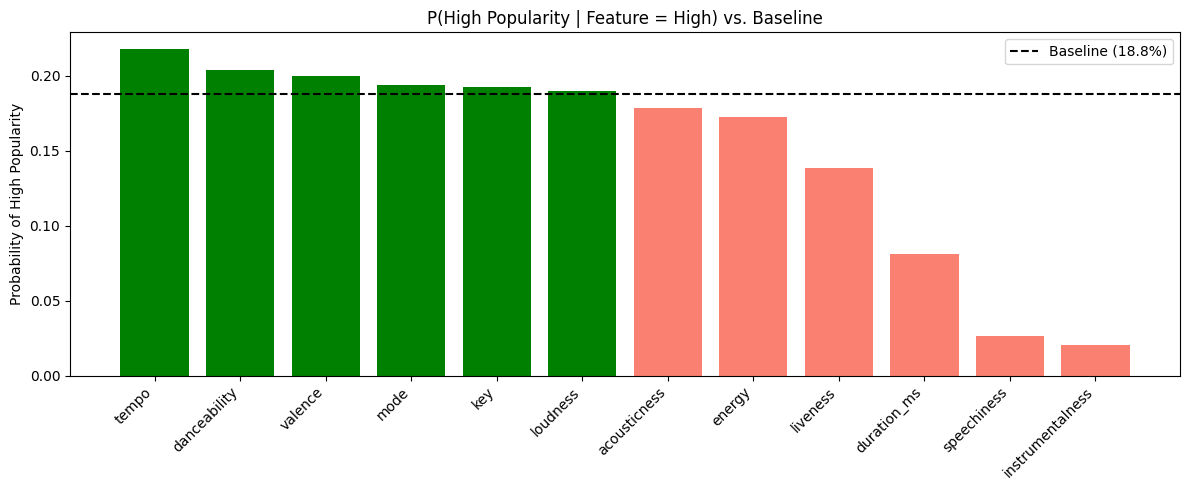

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_features = [c for c in binned_columns if 'track_popularity' not in c]
baseline = (df_transactions['track_popularity_binned'] == 'High').mean()

probs = {}
for f in plot_features:
    probs[f] = (
        df_transactions[df_transactions[f] == 'High']['track_popularity_binned'] == 'High'
    ).mean()

# Sort by distance from baseline
sorted_probs = dict(sorted(probs.items(), key=lambda x: x[1], reverse=True))
labels = [k.replace('_binned', '') for k in sorted_probs.keys()]
values = list(sorted_probs.values())
colors = ['green' if v > baseline else 'salmon' for v in values]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.1%})')
ax.set_title('P(High Popularity | Feature = High) vs. Baseline')
ax.set_ylabel('Probability of High Popularity')
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('cond_prob_chart.png', dpi=150)
plt.show()

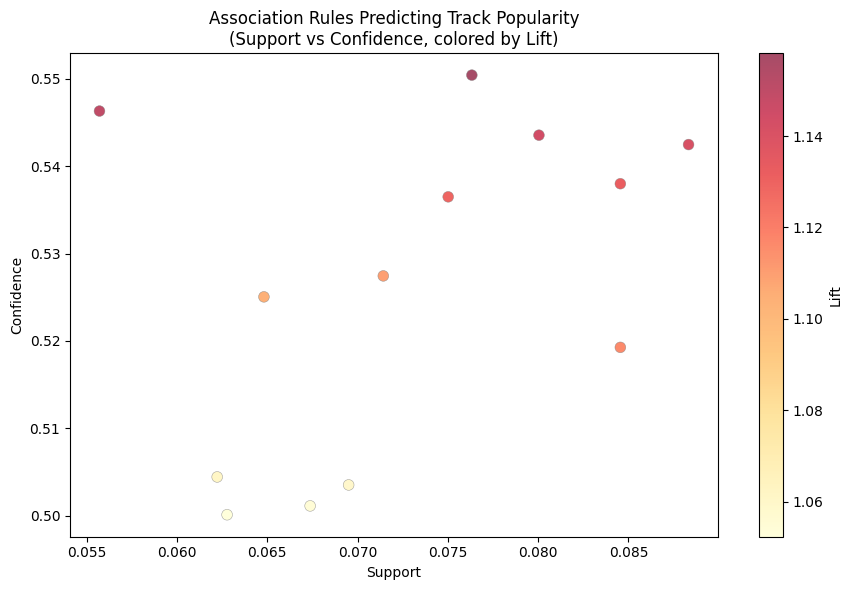

In [ ]:
pop_rules = rules[rules['consequents'].apply(
    lambda x: any('track_popularity' in i for i in x)
)]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    pop_rules['support'],
    pop_rules['confidence'],
    c=pop_rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.4,
    s=60
)
plt.colorbar(sc, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules Predicting Track Popularity\n(Support vs Confidence, colored by Lift)')
plt.tight_layout()
plt.savefig('rules_scatter.png', dpi=150)
plt.show()

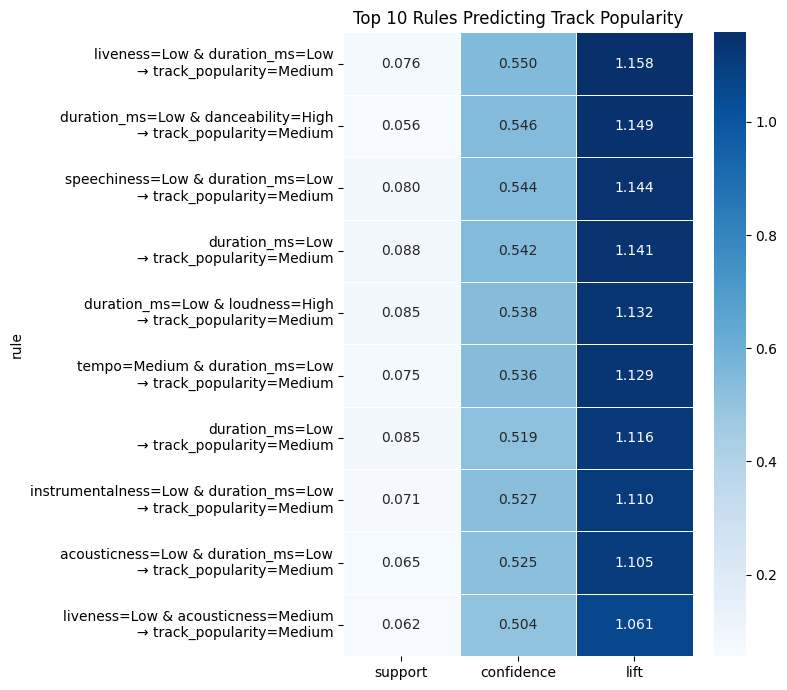

In [ ]:
import seaborn as sns

top = (rules[rules['consequents'].apply(lambda x: any('track_popularity' in i for i in x))]
       .sort_values('lift', ascending=False)
       .head(10)
       .copy())

top['rule'] = top.apply(
    lambda r: ' & '.join([i.replace('_binned','') for i in r['antecedents']])
              + '\n→ ' + list(r['consequents'])[0].replace('_binned',''),
    axis=1
)

heatmap_data = top.set_index('rule')[['support', 'confidence', 'lift']]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Top 10 Rules Predicting Track Popularity')
plt.tight_layout()
plt.savefig('rules_heatmap.png', dpi=150)
plt.show()